# RNN and LSTM from Scratch

Forward pass, **backpropagation through time (BPTT)** and the Adam optimiser
are all written by hand in NumPy. No PyTorch, no TensorFlow, no autograd.
We build a vanilla RNN first, then an LSTM, train both under identical
conditions and compare them on the same inputs.

**Task.** Sequence classification on the `digits` dataset bundled with
scikit-learn (1797 handwritten digits, 8x8 grayscale, nothing to download).
Each image is read **one row at a time**, so a single sample becomes a
sequence of `T = 8` timesteps carrying `D = 8` pixel intensities each.
The network reads the rows top to bottom and classifies the digit from its
final hidden state.

```
 x_1  ->  x_2  -> ... ->  x_8          (rows of the image)
  |        |               |
 h_1  ->  h_2  -> ... ->  h_8  ->  softmax over 10 classes
```

> The model, optimiser and training cells are generated from the production
> package in `seqnet/` (`python scripts/build_notebook.py`), so what you read
> here is exactly what the API serves. See section 12 for running it.

**Contents**
1. Data
2. The RNN (forward pass)
3. Loss
4. Backpropagation through time
5. Adam, by hand
6. Gradient check
7. Training
8. Results
9. The LSTM
10. BPTT through an LSTM
11. RNN vs LSTM, side by side
12. Production code
13. Things to try

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.set_printoptions(precision=3, suppress=True)
RNN_COLOR, LSTM_COLOR = "#2a78d6", "#eb6834"

## 1. Data

`digits.images` has shape `(N, 8, 8)`. We divide by 16 (pixel values run 0-16)
and reinterpret the two image axes as **(timestep, feature)**: row *t* of the
image becomes input vector `x_t`.

In [2]:
digits = load_digits()
X = digits.images / 16.0          # (N, 8, 8) -> (N, T=8, D=8), scaled to [0, 1]
y = digits.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y)

print("train:", X_tr.shape, "  test:", X_te.shape)
print("(samples, timesteps, features per timestep)")
print("classes:", np.unique(y))

train: (1437, 8, 8)   test: (360, 8, 8)
(samples, timesteps, features per timestep)
classes: [0 1 2 3 4 5 6 7 8 9]


Here is what "reading an image as a sequence" actually means: the picture on
the left, and on the right the same 8 rows laid out as the 8 input vectors the
RNN receives one after another.

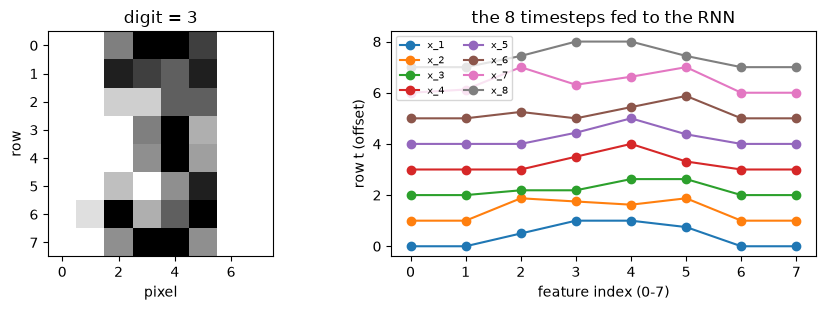

In [3]:
i = 0
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))

ax[0].imshow(X_tr[i], cmap="gray_r")
ax[0].set_title(f"digit = {y_tr[i]}")
ax[0].set_xlabel("pixel"); ax[0].set_ylabel("row")

for t in range(8):
    ax[1].plot(X_tr[i, t] + t, marker="o", label=f"x_{t+1}")
ax[1].set_title("the 8 timesteps fed to the RNN")
ax[1].set_xlabel("feature index (0-7)"); ax[1].set_ylabel("row t (offset)")
ax[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## 2. The RNN

At every timestep the network mixes the current input with what it already
remembers:

$$a_t = x_t W_{xh} + h_{t-1} W_{hh} + b_h$$
$$h_t = \tanh(a_t)$$

and after the last timestep it reads the answer off the final hidden state:

$$\text{logits} = h_T W_{hy} + b_y$$

`h_0` is the zero vector. The crucial detail is that $W_{xh}$, $W_{hh}$ and
$b_h$ are the **same** parameters at every timestep - that weight sharing is
what makes it recurrent, and it is what makes the backward pass interesting.

We work on whole mini-batches, so `X` is `(B, T, D)` and `h` is `(B, H)`.

## 3. Loss

Softmax cross-entropy. Subtracting the row max before exponentiating keeps
`exp` from overflowing. The gradient collapses to the well-known
$\text{softmax}(z) - y_{\text{onehot}}$, divided by the batch size because we
average the loss.

These helpers are shared by both models. `sigmoid` is only needed by the LSTM;
writing it as $\tfrac12(1 + \tanh(x/2))$ is algebraically identical to
$1 / (1 + e^{-x})$ but cannot overflow.

In [4]:
def sigmoid(x):
    # Algebraically identical to 1 / (1 + exp(-x)) but never overflows.
    return 0.5 * (1.0 + np.tanh(0.5 * x))


def softmax(logits):
    z = logits - logits.max(axis=-1, keepdims=True)       # stability
    exp = np.exp(z)
    return exp / exp.sum(axis=-1, keepdims=True)


def softmax_cross_entropy(logits, y):
    """Mean cross-entropy over the batch and its gradient w.r.t. the logits."""
    probs = softmax(logits)

    B = logits.shape[0]
    loss = -np.log(probs[np.arange(B), y] + 1e-12).mean()

    dlogits = probs.copy()
    dlogits[np.arange(B), y] -= 1.0
    dlogits /= B
    return loss, dlogits

## 4. Backpropagation through time

Start at the output and walk backwards through the sequence:

$$\frac{\partial L}{\partial h_T} = \frac{\partial L}{\partial \text{logits}} W_{hy}^\top$$

then for $t = T, T-1, \dots, 1$:

$$\delta_t = \frac{\partial L}{\partial h_t} \odot (1 - h_t^2)
\qquad\text{since}\quad \tanh'(a) = 1 - \tanh(a)^2$$

$$\frac{\partial L}{\partial W_{xh}} \mathrel{+}= x_t^\top \delta_t,
\qquad \frac{\partial L}{\partial W_{hh}} \mathrel{+}= h_{t-1}^\top \delta_t,
\qquad \frac{\partial L}{\partial b_h} \mathrel{+}= \sum_B \delta_t$$

$$\frac{\partial L}{\partial h_{t-1}} = \delta_t W_{hh}^\top$$

Two things to notice:

* The parameter gradients **accumulate with `+=`** across timesteps, because
  the same weights were used at each step.
* `dh` is repeatedly multiplied by $W_{hh}^\top$ on its way back. Over long
  sequences that product either shrinks to nothing (**vanishing gradients**)
  or blows up (**exploding gradients**). Clipping handles the second case;
  the first is what LSTMs and GRUs were invented to fix.

The forward pass and BPTT live in the class below. `trace` is used later to
look inside the model: it returns every hidden state and what the output layer
would predict if the image stopped after row *t*.

In [5]:
class RNN:
    name = "rnn"

    def __init__(self, input_size, hidden_size, output_size, clip=5.0, seed=0):
        r = np.random.default_rng(seed)
        self.H = hidden_size
        self.clip = clip
        self.config = {"input_size": input_size, "hidden_size": hidden_size,
                       "output_size": output_size, "clip": clip, "seed": seed}
        # Xavier-style scaling keeps initial activations in a sane range.
        self.params = {
            "Wxh": r.normal(0, 1 / np.sqrt(input_size),  (input_size,  hidden_size)),
            "Whh": r.normal(0, 1 / np.sqrt(hidden_size), (hidden_size, hidden_size)),
            "bh":  np.zeros(hidden_size),
            "Why": r.normal(0, 1 / np.sqrt(hidden_size), (hidden_size, output_size)),
            "by":  np.zeros(output_size),
        }

    # ---------------- forward ----------------
    def forward(self, X):
        """X: (B, T, D) -> logits (B, C), plus the cache needed for BPTT."""
        p = self.params
        B, T, _ = X.shape

        h = np.zeros((B, self.H))
        hs = [h]                                  # hs[t] == h_t, hs[0] == h_0 == 0
        for t in range(T):
            a = X[:, t] @ p["Wxh"] + h @ p["Whh"] + p["bh"]
            h = np.tanh(a)
            hs.append(h)

        logits = h @ p["Why"] + p["by"]           # only the last state is read
        return logits, (X, hs)

    # ---------------- backward (BPTT) ----------------
    def backward(self, dlogits, cache):
        p = self.params
        X, hs = cache
        T = X.shape[1]
        grads = {k: np.zeros_like(v) for k, v in p.items()}

        grads["Why"] = hs[-1].T @ dlogits
        grads["by"]  = dlogits.sum(axis=0)
        dh = dlogits @ p["Why"].T                 # gradient flowing into h_T

        for t in reversed(range(T)):
            h_t, h_prev = hs[t + 1], hs[t]
            da = dh * (1.0 - h_t ** 2)            # tanh'(a) = 1 - tanh(a)^2

            grads["Wxh"] += X[:, t].T @ da        # += : weights are shared
            grads["Whh"] += h_prev.T  @ da
            grads["bh"]  += da.sum(axis=0)

            dh = da @ p["Whh"].T                  # hand the gradient to h_{t-1}

        for g in grads.values():                  # tame exploding gradients
            np.clip(g, -self.clip, self.clip, out=g)
        return grads

    # ---------------- inference ----------------
    def predict_proba(self, X):
        return softmax(self.forward(X)[0])

    def predict(self, X):
        return self.forward(X)[0].argmax(axis=1)

    def trace(self, X):
        """Per-timestep internals: hidden states and what the output layer
        would predict if the sequence stopped after row t."""
        _, (_, hs) = self.forward(X)
        hidden = np.stack(hs[1:], axis=1)                     # (B, T, H)
        step_logits = hidden @ self.params["Why"] + self.params["by"]
        return {"hidden": hidden, "step_probs": softmax(step_logits)}

## 5. Adam, by hand

Per-parameter adaptive step sizes from a running mean (`m`) and running
uncentred variance (`v`) of the gradients, both bias-corrected because they
start at zero.

In [6]:
class Adam:
    def __init__(self, params, lr=2e-3, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}
        self.t = 0

    def step(self, params, grads):
        self.t += 1
        for k in params:
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * grads[k]
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * grads[k] ** 2
            m_hat = self.m[k] / (1 - self.b1 ** self.t)
            v_hat = self.v[k] / (1 - self.b2 ** self.t)
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

## 6. Gradient check

Hand-derived gradients are easy to get subtly wrong, and a wrong gradient
usually still *trains a bit*, which is why bugs here hide so well. So before
training anything, compare each analytic gradient against a central finite
difference

$$\frac{\partial L}{\partial \theta} \approx \frac{L(\theta + \epsilon) - L(\theta - \epsilon)}{2\epsilon}$$

on a tiny random problem. A relative error below about `1e-6` means the
backward pass is correct.

In [7]:
def gradient_check(net, X, y, rng, eps=1e-5):
    """Compare one random entry of every analytic gradient with a central
    finite difference. Returns {param: (analytic, numeric, relative_error)}."""
    logits, cache = net.forward(X)
    _, dlogits = softmax_cross_entropy(logits, y)
    grads = net.backward(dlogits, cache)

    report = {}
    for name, W in net.params.items():
        idx = tuple(rng.integers(0, s) for s in W.shape)   # one random entry
        orig = W[idx]

        W[idx] = orig + eps
        loss_p, _ = softmax_cross_entropy(net.forward(X)[0], y)
        W[idx] = orig - eps
        loss_m, _ = softmax_cross_entropy(net.forward(X)[0], y)
        W[idx] = orig

        numeric  = (loss_p - loss_m) / (2 * eps)
        analytic = grads[name][idx]
        rel = abs(numeric - analytic) / max(1e-12, abs(numeric) + abs(analytic))
        report[name] = (float(analytic), float(numeric), float(rel))
    return report

In [8]:
def print_gradient_check(model_cls, seed=1):
    rng = np.random.default_rng(seed)
    net = model_cls(4, 6, 3, seed=seed)
    X = rng.normal(size=(5, 7, 4))
    y = rng.integers(0, 3, size=5)

    report = gradient_check(net, X, y, rng)
    for name, (analytic, numeric, rel) in report.items():
        print(f"  {name:4s} analytic={analytic: .6e}  numeric={numeric: .6e}  rel_err={rel:.2e}")
    worst = max(rel for _, _, rel in report.values())
    print(f"\n  worst relative error: {worst:.2e} -> {'PASS' if worst < 1e-6 else 'FAIL'}")

print_gradient_check(RNN)

  Wxh  analytic=-1.406428e-01  numeric=-1.406428e-01  rel_err=5.93e-11
  Whh  analytic=-7.892544e-02  numeric=-7.892544e-02  rel_err=8.32e-12
  bh   analytic=-1.029027e-01  numeric=-1.029027e-01  rel_err=5.94e-11
  Why  analytic= 1.238565e-01  numeric= 1.238565e-01  rel_err=4.13e-13
  by   analytic= 3.789211e-01  numeric= 3.789211e-01  rel_err=3.25e-12

  worst relative error: 5.94e-11 -> PASS


## 7. Training

Mini-batch Adam, reshuffling the training set every epoch. We record the loss
and both accuracies each epoch so we can plot the curves afterwards.

The shuffling RNG is passed in explicitly. Later the LSTM gets a fresh RNG
with the same seed, so both models see **exactly the same mini-batches in the
same order**, and the comparison is fair.

In [9]:
def fit(net, X_tr, y_tr, X_te, y_te, epochs=30, batch_size=64, lr=2e-3,
        rng=None, log_every=5, log=print):
    rng = np.random.default_rng(0) if rng is None else rng
    opt = Adam(net.params, lr=lr)
    n = len(X_tr)
    history = {"loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        order = rng.permutation(n)
        running = 0.0

        for i in range(0, n, batch_size):
            idx = order[i:i + batch_size]
            Xb, yb = X_tr[idx], y_tr[idx]

            logits, cache = net.forward(Xb)             # forward
            loss, dlogits = softmax_cross_entropy(logits, yb)
            grads = net.backward(dlogits, cache)        # BPTT
            opt.step(net.params, grads)                 # update

            running += loss * len(idx)

        tr_acc = float((net.predict(X_tr) == y_tr).mean())
        te_acc = float((net.predict(X_te) == y_te).mean())
        history["loss"].append(running / n)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)

        if log and (epoch == 1 or epoch % log_every == 0):
            log(f"  [{net.name}] epoch {epoch:3d} | loss {running / n:.4f} "
                f"| train acc {tr_acc:.3f} | test acc {te_acc:.3f}")
    return history

In [10]:
SETTINGS = dict(epochs=30, batch_size=64, lr=2e-3)

rnn = RNN(input_size=8, hidden_size=64, output_size=10, seed=42)
rnn_history = fit(rnn, X_tr, y_tr, X_te, y_te, rng=np.random.default_rng(0), **SETTINGS)

print(f"\nfinal test accuracy: {(rnn.predict(X_te) == y_te).mean():.4f}")

  [rnn] epoch   1 | loss 1.8491 | train acc 0.727 | test acc 0.719
  [rnn] epoch   5 | loss 0.2659 | train acc 0.958 | test acc 0.947
  [rnn] epoch  10 | loss 0.1008 | train acc 0.985 | test acc 0.964


  [rnn] epoch  15 | loss 0.0514 | train acc 0.997 | test acc 0.972
  [rnn] epoch  20 | loss 0.0259 | train acc 1.000 | test acc 0.981
  [rnn] epoch  25 | loss 0.0183 | train acc 1.000 | test acc 0.983


  [rnn] epoch  30 | loss 0.0091 | train acc 1.000 | test acc 0.983

final test accuracy: 0.9833


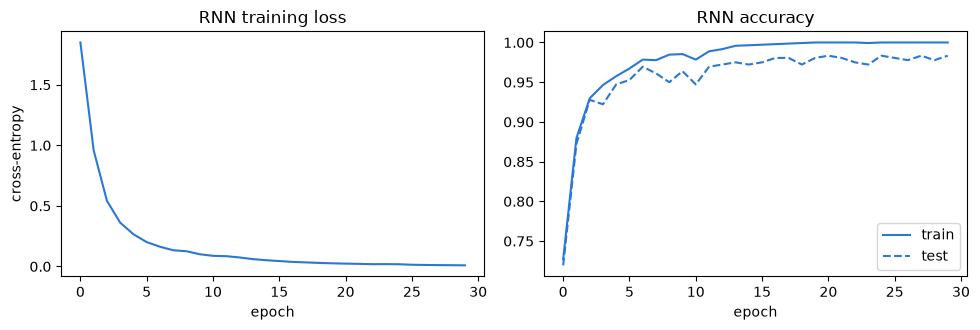

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(rnn_history["loss"], color=RNN_COLOR); ax[0].set_title("RNN training loss")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cross-entropy")

ax[1].plot(rnn_history["train_acc"], label="train", color=RNN_COLOR)
ax[1].plot(rnn_history["test_acc"], label="test", color=RNN_COLOR, linestyle="--")
ax[1].set_title("RNN accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

The gap that opens between the two accuracy curves is ordinary overfitting:
the model memorises the training set while test accuracy flattens out.

## 8. Results

Confusion matrix, then a look at the digits it actually got wrong.

In [12]:
def print_confusion(y_true, y_pred):
    cm = np.zeros((10, 10), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    print("rows = true, cols = predicted\n")
    print("     " + " ".join(f"{c:3d}" for c in range(10)))
    for i, row in enumerate(cm):
        print(f"  {i}  " + " ".join(f"{v:3d}" for v in row))


def show_mistakes(y_true, y_pred, title, k_max=8):
    wrong = np.where(y_pred != y_true)[0]
    print(f"{title}: {len(wrong)} misclassified out of {len(y_true)}")
    if len(wrong):
        k = min(k_max, len(wrong))
        fig, axes = plt.subplots(1, k, figsize=(1.5 * k, 2))
        for ax_, j in zip(np.atleast_1d(axes), wrong[:k]):
            ax_.imshow(X_te[j], cmap="gray_r")
            ax_.set_title(f"{y_true[j]} -> {y_pred[j]}", fontsize=9)
            ax_.axis("off")
        plt.tight_layout(); plt.show()


rnn_pred = rnn.predict(X_te)
print_confusion(y_te, rnn_pred)

rows = true, cols = predicted

       0   1   2   3   4   5   6   7   8   9
  0   36   0   0   0   0   0   0   0   0   0
  1    0  36   0   0   0   0   0   0   0   0
  2    0   1  34   0   0   0   0   0   0   0
  3    0   0   0  36   0   0   0   0   1   0
  4    0   0   0   0  35   0   0   0   1   0
  5    0   0   0   0   0  37   0   0   0   0
  6    0   0   0   0   0   1  35   0   0   0
  7    0   0   0   0   0   0   0  36   0   0
  8    0   2   0   0   0   0   0   0  33   0
  9    0   0   0   0   0   0   0   0   0  36


RNN: 6 misclassified out of 360


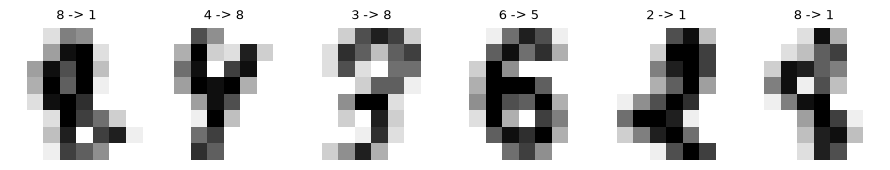

In [13]:
show_mistakes(y_te, rnn_pred, "RNN")

## 9. The LSTM

The RNN's memory is rewritten wholesale at every step: $h_t = \tanh(\dots h_{t-1} W_{hh})$.
Anything it wants to keep has to survive a matrix multiply and a squashing
nonlinearity *every* timestep, and so does the gradient on the way back.

A **Long Short-Term Memory** cell adds a second state, the **cell** $c_t$, which
is updated *additively* and guarded by three gates. One matrix computes all
four pre-activations at once, which are then split into equal quarters:

$$a_t = x_t W_x + h_{t-1} W_h + b = [\,a^i_t,\; a^f_t,\; a^o_t,\; a^g_t\,]$$

$$i_t = \sigma(a^i_t) \quad \text{input gate: how much new information to write}$$
$$f_t = \sigma(a^f_t) \quad \text{forget gate: how much old memory to keep}$$
$$o_t = \sigma(a^o_t) \quad \text{output gate: how much memory to expose}$$
$$g_t = \tanh(a^g_t) \quad \text{candidate values}$$

$$c_t = f_t \odot c_{t-1} + i_t \odot g_t$$
$$h_t = o_t \odot \tanh(c_t)$$

The output layer is unchanged: $\text{logits} = h_T W_{hy} + b_y$.

Two initialisation details:

* $W_x$ has shape `(D, 4H)` and $W_h$ `(H, 4H)`, stacked in the order `[i, f, o, g]`.
* The forget-gate bias starts at **1**, so $f_t \approx 0.73$ at the start of
  training. The cell remembers by default and learns *when to forget*, which
  is the standard trick for getting LSTMs to train quickly.

With the same `H = 64` the LSTM has roughly 4x the recurrent parameters of the RNN.

## 10. BPTT through an LSTM

Walk backwards exactly as before, but now two gradients flow between
timesteps: $\partial L/\partial h$ and $\partial L/\partial c$. At the last
step $\partial L/\partial c_T$ starts at zero, because nothing reads $c_T$
except $h_T$.

For $t = T, \dots, 1$, with $\partial L/\partial h_t$ arriving from above:

$$\frac{\partial L}{\partial o_t} = \frac{\partial L}{\partial h_t} \odot \tanh(c_t)$$

$$\frac{\partial L}{\partial c_t} \mathrel{+}= \frac{\partial L}{\partial h_t} \odot o_t \odot \big(1 - \tanh^2(c_t)\big)
\qquad\text{(the path through } h_t\text{, added to the one from } c_{t+1}\text{)}$$

$$\frac{\partial L}{\partial i_t} = \frac{\partial L}{\partial c_t} \odot g_t, \qquad
\frac{\partial L}{\partial f_t} = \frac{\partial L}{\partial c_t} \odot c_{t-1}, \qquad
\frac{\partial L}{\partial g_t} = \frac{\partial L}{\partial c_t} \odot i_t$$

Push each through its nonlinearity ($\sigma' = \sigma(1-\sigma)$, $\tanh' = 1-\tanh^2$)
and stack them back into one vector $\delta_t = [\delta^i_t, \delta^f_t, \delta^o_t, \delta^g_t]$.
The weight gradients then look exactly like the RNN's:

$$\frac{\partial L}{\partial W_x} \mathrel{+}= x_t^\top \delta_t, \qquad
\frac{\partial L}{\partial W_h} \mathrel{+}= h_{t-1}^\top \delta_t, \qquad
\frac{\partial L}{\partial b} \mathrel{+}= \sum_B \delta_t$$

and the two states hand their gradients to $t-1$:

$$\frac{\partial L}{\partial h_{t-1}} = \delta_t W_h^\top, \qquad
\boxed{\frac{\partial L}{\partial c_{t-1}} = \frac{\partial L}{\partial c_t} \odot f_t}$$

The boxed line is the whole point. Along the cell path the gradient is scaled
**only by the forget gate**: no weight matrix, no $\tanh'$. When the network
chooses to remember ($f_t \approx 1$), the gradient passes back almost
untouched. This is the "constant error carousel" that lets LSTMs learn
dependencies over far more timesteps than a vanilla RNN.

In [14]:
class LSTM:
    name = "lstm"

    def __init__(self, input_size, hidden_size, output_size, clip=5.0, seed=0):
        r = np.random.default_rng(seed)
        H = self.H = hidden_size
        self.clip = clip
        self.config = {"input_size": input_size, "hidden_size": hidden_size,
                       "output_size": output_size, "clip": clip, "seed": seed}
        # The four gates share one matrix each, stacked in the order [i, f, o, g].
        b = np.zeros(4 * H)
        b[H:2 * H] = 1.0                          # forget-gate bias 1: remember by default
        self.params = {
            "Wx":  r.normal(0, 1 / np.sqrt(input_size),  (input_size,  4 * H)),
            "Wh":  r.normal(0, 1 / np.sqrt(hidden_size), (hidden_size, 4 * H)),
            "b":   b,
            "Why": r.normal(0, 1 / np.sqrt(hidden_size), (hidden_size, output_size)),
            "by":  np.zeros(output_size),
        }

    # ---------------- forward ----------------
    def forward(self, X):
        """X: (B, T, D) -> logits (B, C), plus the cache needed for BPTT."""
        p, H = self.params, self.H
        B, T, _ = X.shape

        h = np.zeros((B, H))
        c = np.zeros((B, H))
        steps = []
        for t in range(T):
            a = X[:, t] @ p["Wx"] + h @ p["Wh"] + p["b"]
            i = sigmoid(a[:, :H])                 # input gate:  how much new info to write
            f = sigmoid(a[:, H:2 * H])            # forget gate: how much old memory to keep
            o = sigmoid(a[:, 2 * H:3 * H])        # output gate: how much memory to expose
            g = np.tanh(a[:, 3 * H:])             # candidate values to write

            h_prev, c_prev = h, c
            c = f * c_prev + i * g                # additive memory update
            tanh_c = np.tanh(c)
            h = o * tanh_c
            steps.append((h_prev, c_prev, i, f, o, g, tanh_c))

        logits = h @ p["Why"] + p["by"]           # only the last state is read
        return logits, (X, steps, h)

    # ---------------- backward (BPTT) ----------------
    def backward(self, dlogits, cache):
        p = self.params
        X, steps, h_T = cache
        T = X.shape[1]
        grads = {k: np.zeros_like(v) for k, v in p.items()}

        grads["Why"] = h_T.T @ dlogits
        grads["by"]  = dlogits.sum(axis=0)
        dh = dlogits @ p["Why"].T                 # gradient flowing into h_T
        dc = np.zeros_like(dh)                    # nothing reads c_T except h_T

        for t in reversed(range(T)):
            h_prev, c_prev, i, f, o, g, tanh_c = steps[t]

            do = dh * tanh_c
            dc = dc + dh * o * (1.0 - tanh_c ** 2)    # two paths into c_t
            di = dc * g
            df = dc * c_prev
            dg = dc * i

            da = np.concatenate([di * i * (1.0 - i),  # sigmoid' = s(1 - s)
                                 df * f * (1.0 - f),
                                 do * o * (1.0 - o),
                                 dg * (1.0 - g ** 2)], axis=1)

            grads["Wx"] += X[:, t].T @ da         # += : weights are shared
            grads["Wh"] += h_prev.T  @ da
            grads["b"]  += da.sum(axis=0)

            dh = da @ p["Wh"].T                   # hand the gradient to h_{t-1}
            dc = dc * f                           # ... and to c_{t-1}, scaled only by f

        for g_ in grads.values():                 # tame exploding gradients
            np.clip(g_, -self.clip, self.clip, out=g_)
        return grads

    # ---------------- inference ----------------
    def predict_proba(self, X):
        return softmax(self.forward(X)[0])

    def predict(self, X):
        return self.forward(X)[0].argmax(axis=1)

    def trace(self, X):
        """Per-timestep internals: hidden and cell states, gate activations,
        and what the output layer would predict if the sequence stopped at row t."""
        _, (_, steps, _) = self.forward(X)
        h_prev, c_prev, i, f, o, g, tanh_c = (np.stack(s, axis=1) for s in zip(*steps))
        hidden = o * tanh_c                                   # (B, T, H)
        step_logits = hidden @ self.params["Why"] + self.params["by"]
        return {"hidden": hidden, "cell": f * c_prev + i * g,
                "gates": {"input": i, "forget": f, "output": o},
                "step_probs": softmax(step_logits)}

Same gradient check, same tolerance. The LSTM's backward pass has many more
places to make a sign or ordering mistake, so this check matters even more here.

In [15]:
print_gradient_check(LSTM)

  Wx   analytic= 1.151915e-02  numeric= 1.151915e-02  rel_err=1.16e-11
  Wh   analytic=-7.593889e-05  numeric=-7.593889e-05  rel_err=4.22e-08
  b    analytic=-8.972923e-03  numeric=-8.972923e-03  rel_err=1.32e-10
  Why  analytic=-2.665458e-02  numeric=-2.665458e-02  rel_err=9.34e-11
  by   analytic= 3.297508e-01  numeric= 3.297508e-01  rel_err=1.33e-11

  worst relative error: 4.22e-08 -> PASS


Train it with **the same** data, hidden size, initialisation seed, epochs,
batch size, learning rate and mini-batch order as the RNN.

In [16]:
lstm = LSTM(input_size=8, hidden_size=64, output_size=10, seed=42)
lstm_history = fit(lstm, X_tr, y_tr, X_te, y_te, rng=np.random.default_rng(0), **SETTINGS)

lstm_pred = lstm.predict(X_te)
print(f"\nfinal test accuracy: {(lstm_pred == y_te).mean():.4f}")

  [lstm] epoch   1 | loss 2.1224 | train acc 0.590 | test acc 0.550


  [lstm] epoch   5 | loss 0.4981 | train acc 0.886 | test acc 0.853


  [lstm] epoch  10 | loss 0.2376 | train acc 0.956 | test acc 0.936


  [lstm] epoch  15 | loss 0.1239 | train acc 0.971 | test acc 0.936


  [lstm] epoch  20 | loss 0.0778 | train acc 0.978 | test acc 0.931


  [lstm] epoch  25 | loss 0.0363 | train acc 0.998 | test acc 0.961


  [lstm] epoch  30 | loss 0.0223 | train acc 0.999 | test acc 0.958

final test accuracy: 0.9583


rows = true, cols = predicted

       0   1   2   3   4   5   6   7   8   9
  0   36   0   0   0   0   0   0   0   0   0
  1    0  35   0   0   1   0   0   0   0   0
  2    0   1  34   0   0   0   0   0   0   0
  3    0   0   1  35   0   0   0   1   0   0
  4    0   0   0   0  34   0   0   0   2   0
  5    0   1   0   0   0  35   0   0   1   0
  6    0   0   0   0   0   1  35   0   0   0
  7    0   0   0   0   0   0   0  36   0   0
  8    0   2   0   0   0   0   0   1  32   0
  9    0   0   0   1   1   1   0   0   0  33
LSTM: 15 misclassified out of 360


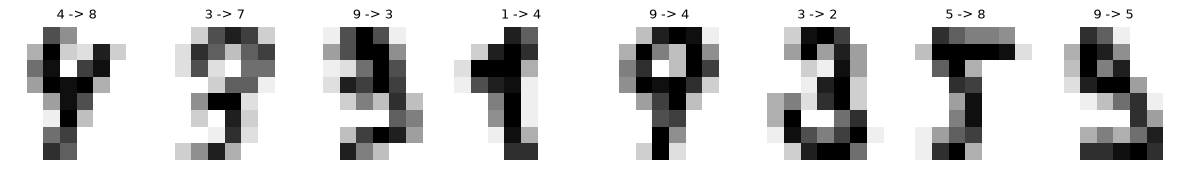

In [17]:
print_confusion(y_te, lstm_pred)
show_mistakes(y_te, lstm_pred, "LSTM")

## 11. RNN vs LSTM, side by side

First the learning curves on one set of axes, then the scoreboard.

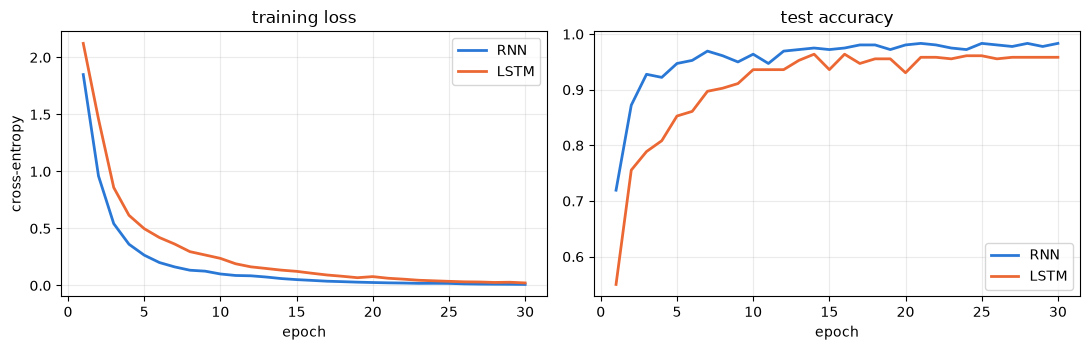

In [18]:
epochs = np.arange(1, SETTINGS["epochs"] + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for name, hist, color in [("RNN", rnn_history, RNN_COLOR), ("LSTM", lstm_history, LSTM_COLOR)]:
    ax[0].plot(epochs, hist["loss"], color=color, lw=2, label=name)
    ax[1].plot(epochs, hist["test_acc"], color=color, lw=2, label=name)

ax[0].set_title("training loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cross-entropy")
ax[1].set_title("test accuracy"); ax[1].set_xlabel("epoch")
for a in ax:
    a.legend(); a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

In [19]:
def n_params(net):
    return sum(v.size for v in net.params.values())

rnn_ok, lstm_ok = rnn_pred == y_te, lstm_pred == y_te

print(f"{'':6s}{'params':>8s}{'train acc':>11s}{'test acc':>10s}")
for name, net, hist, ok in [("RNN", rnn, rnn_history, rnn_ok), ("LSTM", lstm, lstm_history, lstm_ok)]:
    print(f"{name:6s}{n_params(net):8d}{hist['train_acc'][-1]:11.3f}{ok.mean():10.3f}")

print(f"\nboth correct        {np.sum(rnn_ok & lstm_ok):4d}")
print(f"only RNN correct    {np.sum(rnn_ok & ~lstm_ok):4d}")
print(f"only LSTM correct   {np.sum(~rnn_ok & lstm_ok):4d}")
print(f"both wrong          {np.sum(~rnn_ok & ~lstm_ok):4d}")
print(f"same prediction     {np.sum(rnn_pred == lstm_pred):4d} / {len(y_te)}")

        params  train acc  test acc
RNN       5322      1.000     0.983
LSTM     19338      0.999     0.958

both correct         343
only RNN correct      11
only LSTM correct      2
both wrong             4
same prediction      346 / 360


### The same input through both models

Pick a test digit the two models disagree on and watch them read it. For each
row *t* we ask: *if the image ended here, how much probability would the model
give the true digit?* (`trace` applies the output layer to every intermediate
hidden state.)

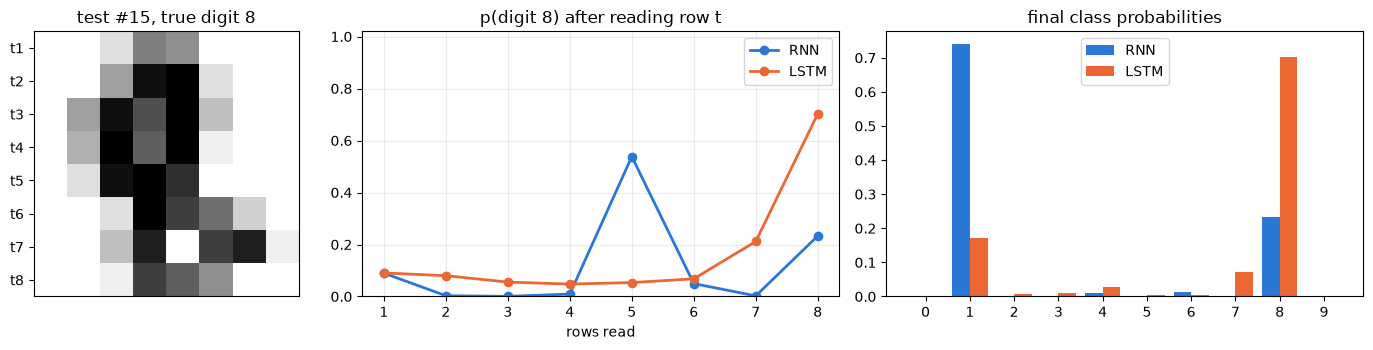

RNN  predicts 1   LSTM predicts 8   truth 8


In [20]:
disagree = np.where(rnn_pred != lstm_pred)[0]
j = int(disagree[0]) if len(disagree) else 0
x = X_te[j:j + 1]
tr_rnn, tr_lstm = rnn.trace(x), lstm.trace(x)
rows = np.arange(1, 9)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6), gridspec_kw={"width_ratios": [1, 1.6, 1.6]})
ax[0].imshow(X_te[j], cmap="gray_r")
ax[0].set_title(f"test #{j}, true digit {y_te[j]}")
ax[0].set_yticks(range(8), [f"t{t + 1}" for t in range(8)]); ax[0].set_xticks([])

for name, tr, color in [("RNN", tr_rnn, RNN_COLOR), ("LSTM", tr_lstm, LSTM_COLOR)]:
    ax[1].plot(rows, tr["step_probs"][0, :, y_te[j]], marker="o", color=color, lw=2, label=name)
ax[1].set_ylim(0, 1.02); ax[1].set_xlabel("rows read"); ax[1].grid(alpha=0.25); ax[1].legend()
ax[1].set_title(f"p(digit {y_te[j]}) after reading row t")

digits_ = np.arange(10)
ax[2].bar(digits_ - 0.2, tr_rnn["step_probs"][0, -1], width=0.4, color=RNN_COLOR, label="RNN")
ax[2].bar(digits_ + 0.2, tr_lstm["step_probs"][0, -1], width=0.4, color=LSTM_COLOR, label="LSTM")
ax[2].set_xticks(digits_); ax[2].set_title("final class probabilities"); ax[2].legend()
plt.tight_layout(); plt.show()

print(f"RNN  predicts {rnn_pred[j]}   LSTM predicts {lstm_pred[j]}   truth {y_te[j]}")

And what happens *inside*. Left: the LSTM's gates, averaged over its 64 units,
row by row. Right: the hidden states of both networks (rows = timesteps,
columns = units, red positive, blue negative).

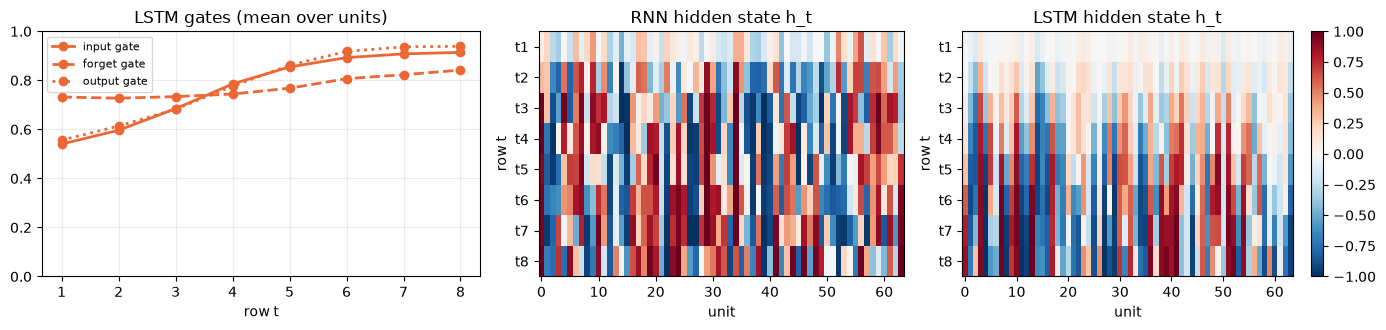

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4), gridspec_kw={"width_ratios": [1.2, 1, 1]})
for gate, style in [("input", "-"), ("forget", "--"), ("output", ":")]:
    ax[0].plot(rows, tr_lstm["gates"][gate][0].mean(axis=1), style, marker="o", color=LSTM_COLOR, lw=2, label=f"{gate} gate")
ax[0].set_ylim(0, 1); ax[0].set_xlabel("row t"); ax[0].set_title("LSTM gates (mean over units)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.25)

for a, name, tr in [(ax[1], "RNN", tr_rnn), (ax[2], "LSTM", tr_lstm)]:
    im = a.imshow(tr["hidden"][0], aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
    a.set_title(f"{name} hidden state h_t"); a.set_xlabel("unit"); a.set_ylabel("row t")
    a.set_yticks(range(8), [f"t{t + 1}" for t in range(8)])
fig.colorbar(im, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.show()

### What to take away

* **On this task the plain RNN wins.** It reaches higher test accuracy with about a
  quarter of the parameters and trains roughly 4-5x faster. The LSTM also starts
  slower, as the first epochs of the loss curve show: it has four gates' worth of
  weights to fit with the same 30 epochs and learning rate.
* **Why the LSTM's advantage doesn't show up here:** the sequences are only 8 steps
  long. Vanishing gradients need many multiplications by $W_{hh}^\top$ before they
  bite, and 8 isn't enough, so the RNN's simple memory is sufficient.
* **Where the LSTM does earn its keep:** long sequences where the answer depends on
  something seen far back. Try the `T = 32` experiment in section 13 and compare again.
* The gate plot shows the mechanism: forget gates stay well above zero, so the cell
  carries information across rows instead of rewriting it.

## 12. Production code

The classes above are the code in the `seqnet/` package, which also includes a
training CLI, model artifacts, a FastAPI service and a web UI that runs the
**same input through both models side by side**.

```
seqnet/
  functional.py        sigmoid, softmax, softmax_cross_entropy
  models/rnn.py        RNN   (section 2-4)
  models/lstm.py       LSTM  (section 9-10)
  optim.py             Adam  (section 5)
  training.py          fit, gradient_check (sections 6-7)
  data.py              digits -> (N, 8, 8) sequences
  persistence.py       save / load .npz weights + .json metadata
  train.py             CLI: trains both models with identical settings
  service.py, api.py   FastAPI inference service
web/                   side-by-side comparison UI
tests/                 gradient checks, API tests, notebook-sync test
```

```bash
make install     # venv + dependencies
make train       # writes artifacts/rnn.{npz,json}, artifacts/lstm.{npz,json}
make serve       # http://127.0.0.1:8000
make test
make notebook    # regenerate + re-run this notebook from the package source
```

With the default settings `make train` reproduces the numbers in this notebook
exactly (same split, seeds and batch order).

## 13. Things to try

* **Watch gradients explode.** Set `clip=1e9` and feed longer sequences
  (stack each image 4 times with `np.concatenate([X] * 4, axis=1)` to get
  `T = 32`). The RNN's loss will spike or go `nan`. Put the clipping back and
  it trains again.
* **Watch them vanish, and watch the LSTM not care.** With `T = 32`, print
  `np.abs(dh).mean()` inside both backward loops. The RNN's value shrinks
  steadily as `t` goes back in time; the LSTM's `dc` path decays far more
  slowly. Then train both and compare test accuracy again.
* **Make memory matter.** Only show the digit in the first 8 of 32 timesteps
  and fill the rest with zeros or noise. Now the answer must be carried across
  24 steps, which is exactly the setting the LSTM was designed for.
* **Does order matter?** Shuffle the 8 rows of every image with one fixed
  permutation and retrain. Accuracy barely moves, which tells you this
  particular task does not need much memory. (The web UI's *Reverse rows*
  button shows what trained models do with time reversed.)
* **Add a GRU.** Two gates instead of three, no separate cell. Write the
  class with the same `forward / backward / trace` interface, register it in
  `seqnet/models/__init__.py`, and it shows up in the training CLI.
* **Swap the dataset.** Any data reshaped to `(N, T, D)` works - just change
  `input_size` and `output_size`. Variable-length sequences need masking,
  which this version does not do.
* **Character-level text generation.** Feed one-hot characters, apply `Why`
  at *every* timestep instead of only the last, and add each step's output
  gradient into `dh` inside the backward loop before the nonlinearity's derivative.
* **Deeper or bidirectional.** Stack a second recurrent layer on the hidden
  states of the first, or run a second model over the reversed sequence and
  concatenate the two final states.